### Running Evaluation

In [7]:
# Soft compactness eval

!ftw_ma model test \
  -cfg /opt/app-root/src/gregg-work/ftw-mappingafrica-integration/configs/gregg_softcompactness_5k_nullhandling.yaml \
  -m /opt/app-root/src/gregg-work/outputs/softcompactness_5k_nullhandling/lightning_logs/version_1/checkpoints/last.ckpt \
  --gpu 0 \
  -d /opt/app-root/src \
  -cat /opt/app-root/src/gregg-work/ftw-mappingafrica-integration/data/mappingafrica-catalog.csv \
  -spl validate \
  -o softcompactness_nullhandling_metrics.csv

Running test command
Loading model
Using custom trainer
{}
"backbone":              efficientnet-b7
"class_weights":         [0.05, 0.2, 0.75]
"freeze_backbone":       False
"freeze_decoder":        False
"freeze_decoder_blocks": None
"freeze_encoder_blocks": None
"ignore_index":          3
"in_channels":           4
"loss":                  localtversky_softcompactness
"lr":                    0.001
"model":                 unet
"model_kwargs":          {}
"num_classes":           3
"num_filters":           64
"patch_weights":         False
"patience":              100
Model loaded in 2.93s
Creating dataloader
temporal_options: windowB
normalization_strategy: min_max
normalization_stat_procedure: gab
global_stats: {'min': [203.5], 'max': [4590.4]}
img_clip_val: 0
nodata: None
Selecting :  3930  samples
Created dataloader with 3930 samples in{time.time() - tic:.2f}s
100%|███████████████████████████████████████████| 62/62 [01:44<00:00,  1.69s/it]
Pixel level IoU: 0.5128
Pixel level prec

In [8]:
# Baseline Eval

!ftw_ma model test \
  -cfg /opt/app-root/src/gregg-work/ftw-mappingafrica-integration/configs/gregg_softcompactness_5k_nullhandling.yaml \
  -m /opt/app-root/src/gregg-work/outputs/baseline_5k/lightning_logs/version_2/checkpoints/last.ckpt \
  --gpu 0 \
  -d /opt/app-root/src \
  -cat /opt/app-root/src/gregg-work/ftw-mappingafrica-integration/data/mappingafrica-catalog.csv \
  -spl validate \
  -o baseline_metrics.csv

Running test command
Loading model
Using custom trainer
{}
"backbone":              efficientnet-b7
"class_weights":         [0.05, 0.2, 0.75]
"freeze_backbone":       False
"freeze_decoder":        False
"freeze_decoder_blocks": None
"freeze_encoder_blocks": None
"ignore_index":          3
"in_channels":           4
"loss":                  localtversky
"lr":                    0.001
"model":                 unet
"model_kwargs":          {}
"num_classes":           3
"num_filters":           64
"patch_weights":         False
"patience":              100
Model loaded in 8.93s
Creating dataloader
temporal_options: windowB
normalization_strategy: min_max
normalization_stat_procedure: gab
global_stats: {'min': [203.5], 'max': [4590.4]}
img_clip_val: 0
nodata: None
Selecting :  3930  samples
Created dataloader with 3930 samples in{time.time() - tic:.2f}s
100%|███████████████████████████████████████████| 62/62 [01:50<00:00,  1.79s/it]
Pixel level IoU: 0.5245
Pixel level precision: 0.6669
Pi

### Visualizing Baseline and Softcompactness Predictions

Baseline ZM predictions: 253
Soft Null-Handling ZM predictions: 253
Matching ZM predictions: 253


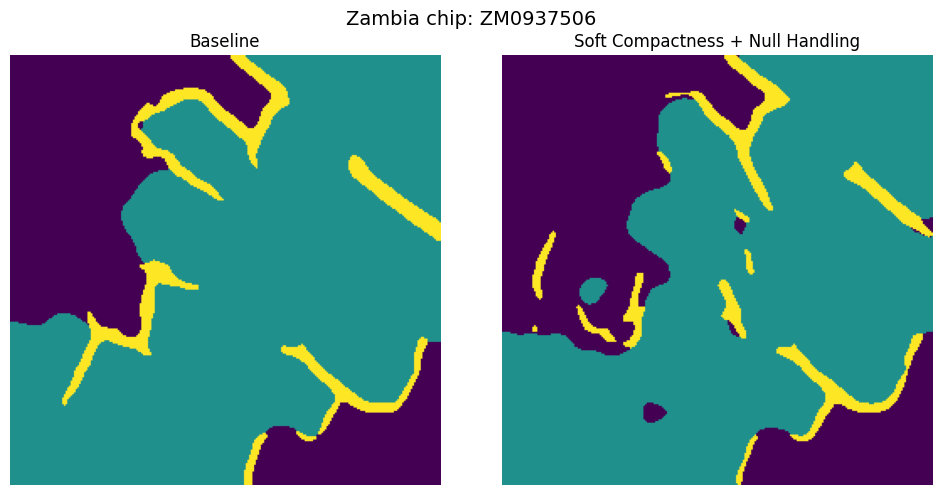

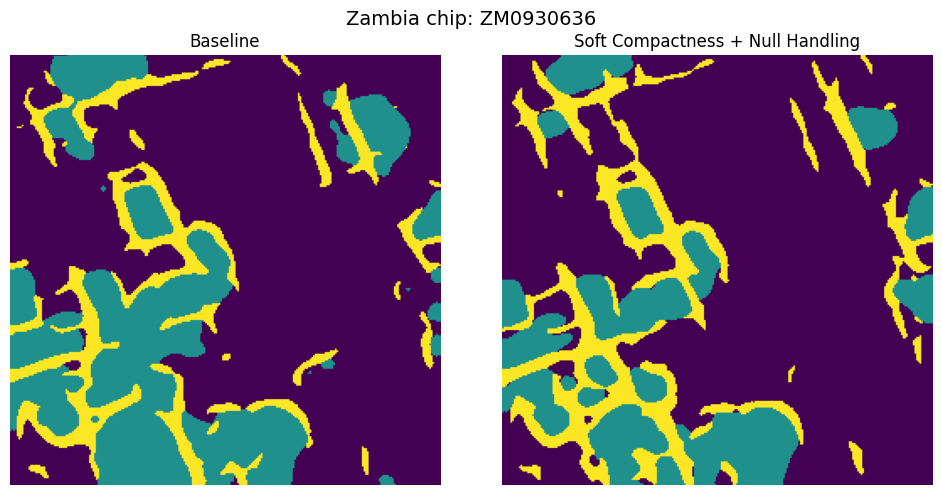

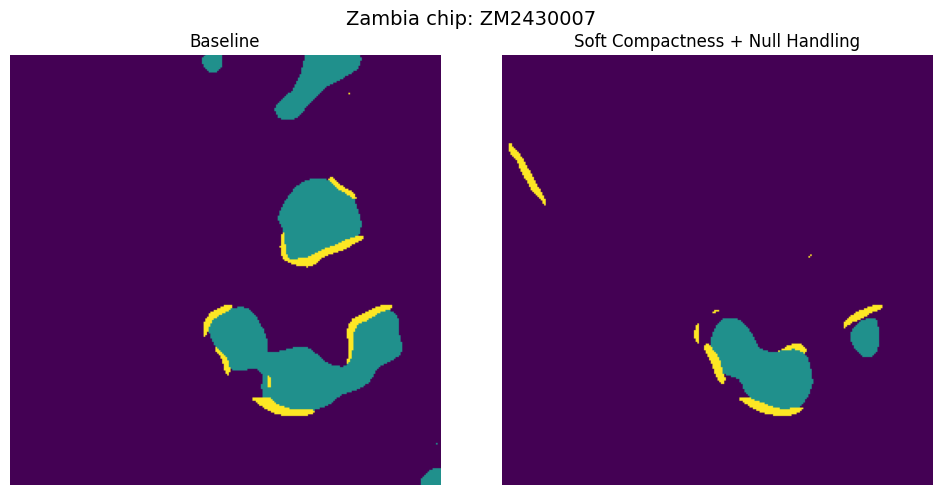

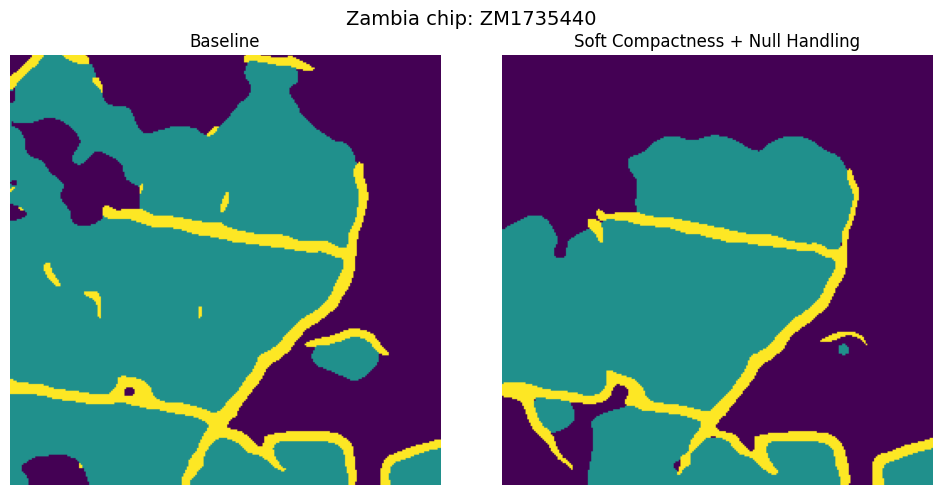

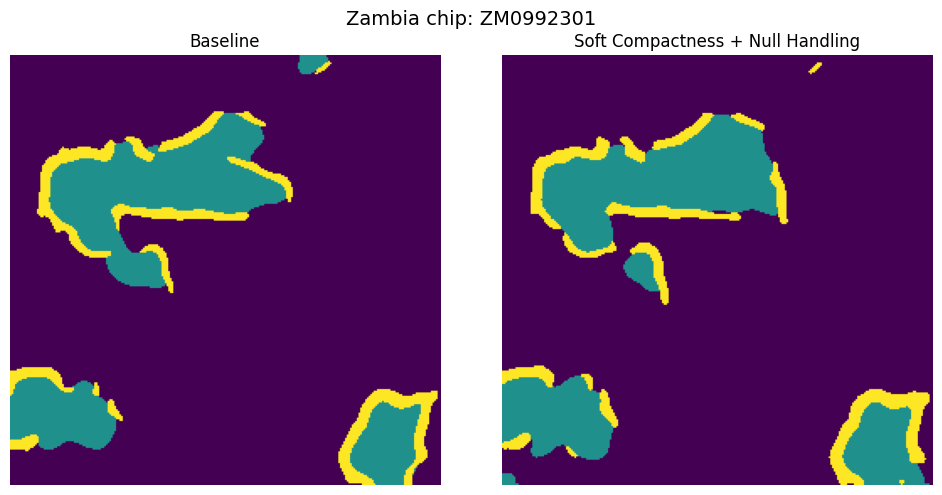

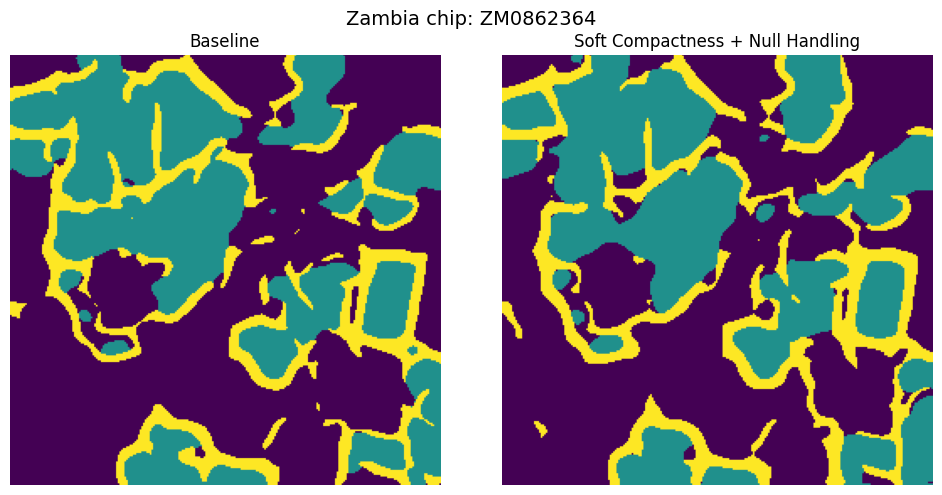

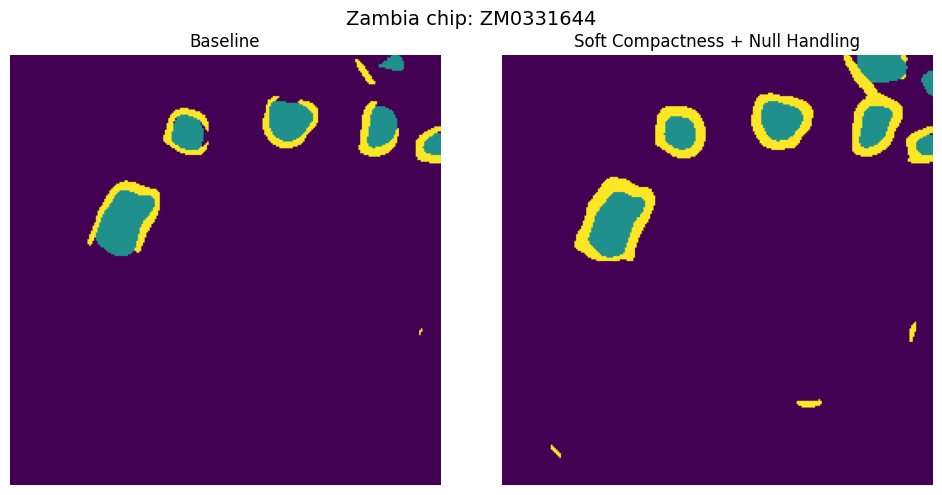

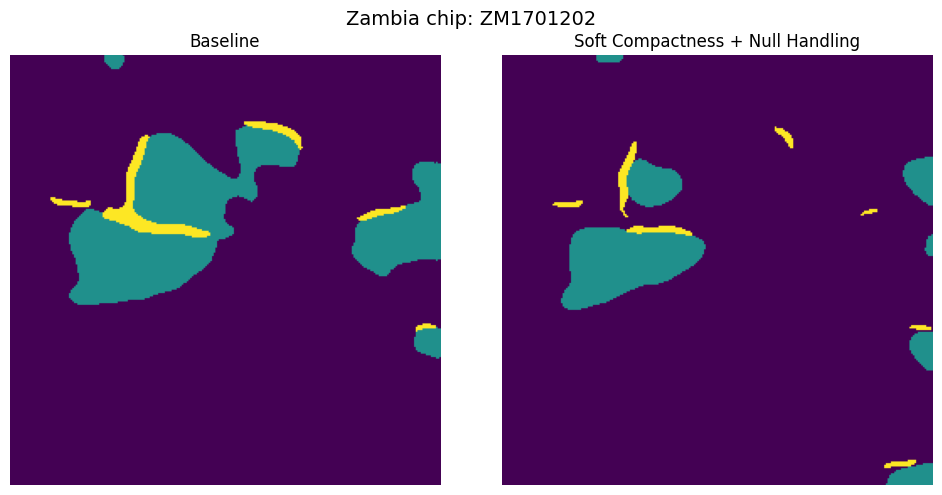

Saved 8 plots to: /opt/app-root/src/working/models/outputs/comparison_plots/zm_random8_baseline_vs_soft_nullhandling


In [2]:
from pathlib import Path
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt

BASELINE_DIR = Path("/opt/app-root/src/working/models/outputs/predictions/baseline_5k/version_2/baseline_5k")

# Updated: soft compactness model retrained with null handling
SOFT_DIR = Path("/opt/app-root/src/working/models/outputs/predictions/softcompactness_5k/version_2/softcompactness_5k")

OUT_DIR = Path("/opt/app-root/src/working/models/outputs/comparison_plots/zm_random8_baseline_vs_soft_nullhandling")
OUT_DIR.mkdir(parents=True, exist_ok=True)

N = 8
# SEED = 42

def read_band(path):
    with rasterio.open(path) as src:
        return src.read(1)

baseline_files = {
    p.stem.replace("_prediction", ""): p
    for p in BASELINE_DIR.glob("ZM*_prediction.tif")
}

soft_files = {
    p.stem.replace("_prediction", ""): p
    for p in SOFT_DIR.glob("ZM*_prediction.tif")
}

common_ids = sorted(set(baseline_files) & set(soft_files))

print("Baseline ZM predictions:", len(baseline_files))
print("Soft Null-Handling ZM predictions:", len(soft_files))
print("Matching ZM predictions:", len(common_ids))

if len(common_ids) == 0:
    raise ValueError("No matching ZM prediction files found.")

# random.seed(SEED)
sample_ids = random.sample(common_ids, min(N, len(common_ids)))

for chip_id in sample_ids:
    baseline = read_band(baseline_files[chip_id])
    soft = read_band(soft_files[chip_id])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(baseline, vmin=0, vmax=2)
    axes[0].set_title("Baseline")

    axes[1].imshow(soft, vmin=0, vmax=2)
    axes[1].set_title("Soft Compactness + Null Handling")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(f"Zambia chip: {chip_id}", fontsize=14)
    plt.tight_layout()

    out_path = OUT_DIR / f"{chip_id}_baseline_vs_soft_nullhandling.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Saved {len(sample_ids)} plots to: {OUT_DIR}")

### Running Makeinstances to vectorize field predictions to polygons

In [4]:
from pathlib import Path
import geopandas as gpd
from tqdm import tqdm

# If makeinstances.py is in the instancemaker repo:
import sys
sys.path.append("/opt/app-root/src/gregg-work/instancemaker/src")

from instancemaker.makeinstances import MakeInstances

# -----------------------------
# Paths
# -----------------------------
BASELINE_PRED_DIR = Path("/opt/app-root/src/working/models/outputs/predictions/baseline_5k/version_2/baseline_5k")
SOFT_PRED_DIR = Path("/opt/app-root/src/working/models/outputs/predictions/softcompactness_5k/version_2/softcompactness_5k")

BASELINE_OUT_DIR = Path("/opt/app-root/src/working/instances_direct/baseline_polygons")
SOFT_OUT_DIR = Path("/opt/app-root/src/working/instances_direct/soft_polygons")

BASELINE_OUT_DIR.mkdir(parents=True, exist_ok=True)
SOFT_OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# MakeInstances object
# -----------------------------
mki = MakeInstances(
    kernel=[
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
    ],
    threshold_type="class",
    class_id=1,
    threshold=0,
    erosion_iterations=0,
    dilation_iterations=0,
)

# -----------------------------
# Polygonize function
# -----------------------------
def polygonize_prediction_folder(pred_dir, out_dir, simplify=0):
    pred_files = sorted(pred_dir.glob("ZM*_prediction.tif"))

    print("Prediction files found:", len(pred_files))
    print("Output folder:", out_dir)

    all_records = []

    for pred_path in tqdm(pred_files):
        chip_id = pred_path.stem.replace("_prediction", "")
        out_path = out_dir / f"{chip_id}_polygons.geojson"

        try:
            gdf = mki.polygonize(
                image=str(pred_path),
                simplify=simplify,
                labeled=False,
                erode_dilate=False,
                polygon_filename=str(out_path),
            )

            gdf["chip_id"] = chip_id
            gdf["source_prediction"] = pred_path.name
            gdf["n_polygons_tile"] = len(gdf)

            all_records.append(gdf)

        except Exception as e:
            print(f"Failed: {pred_path.name}")
            print(e)

    if all_records:
        merged = gpd.GeoDataFrame(
            pd.concat(all_records, ignore_index=True),
            crs=all_records[0].crs
        )
        return merged

    return gpd.GeoDataFrame()


# -----------------------------
# Run baseline + soft compactness
# -----------------------------
import pandas as pd

baseline_gdf = polygonize_prediction_folder(
    BASELINE_PRED_DIR,
    BASELINE_OUT_DIR,
    simplify=0
)

soft_gdf = polygonize_prediction_folder(
    SOFT_PRED_DIR,
    SOFT_OUT_DIR,
    simplify=0
)

print("Baseline polygons:", len(baseline_gdf))
print("Soft compactness polygons:", len(soft_gdf))

Prediction files found: 253
Output folder: /opt/app-root/src/working/instances_direct/baseline_polygons


100%|██████████| 253/253 [00:05<00:00, 46.16it/s]


Prediction files found: 253
Output folder: /opt/app-root/src/working/instances_direct/soft_polygons


100%|██████████| 253/253 [00:03<00:00, 67.22it/s]

Baseline polygons: 3136
Soft compactness polygons: 2788


### Saving vectorized polygons as a geopackage

In [5]:
BASELINE_COMBINED = Path("/opt/app-root/src/working/instances_direct/baseline_all_polygons.gpkg")
SOFT_COMBINED = Path("/opt/app-root/src/working/instances_direct/soft_all_polygons.gpkg")

baseline_gdf.to_file(BASELINE_COMBINED, driver="GPKG")
soft_gdf.to_file(SOFT_COMBINED, driver="GPKG")

print(BASELINE_COMBINED)
print(SOFT_COMBINED)

/opt/app-root/src/working/instances_direct/baseline_all_polygons.gpkg
/opt/app-root/src/working/instances_direct/soft_all_polygons.gpkg


### Visualizing Vectorized Polygons - Baseline vs Softcompactness

Baseline polygons: 3136
Soft polygons: 2788
Common chips: 249
Selected chips:
ZM1874811
ZM0869778
ZM2230341
ZM2324374
ZM1061074
ZM0107632
ZM0883952
ZM2455457


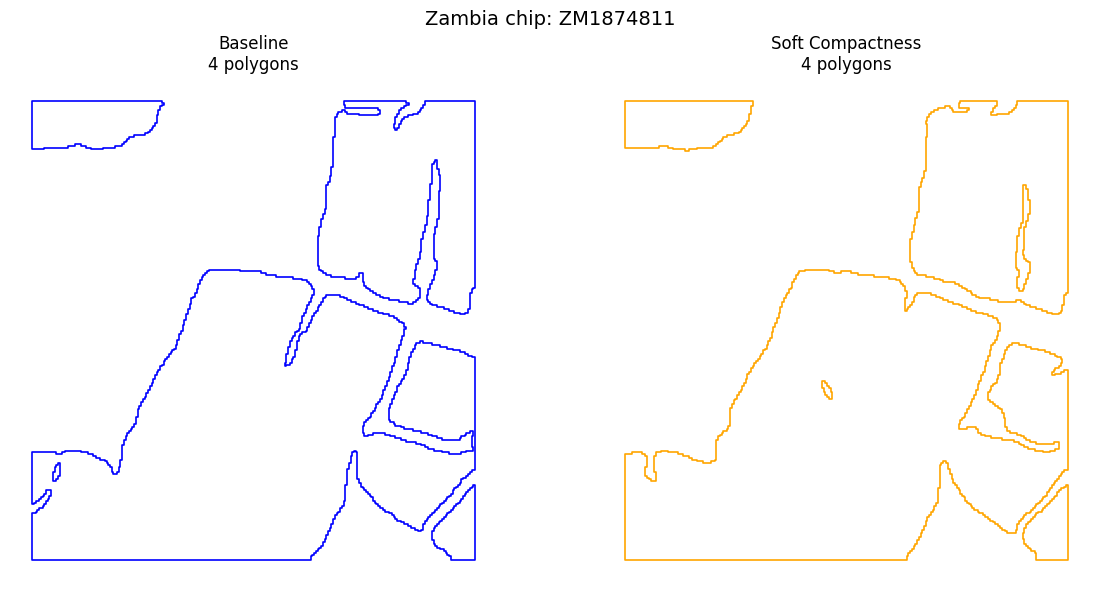

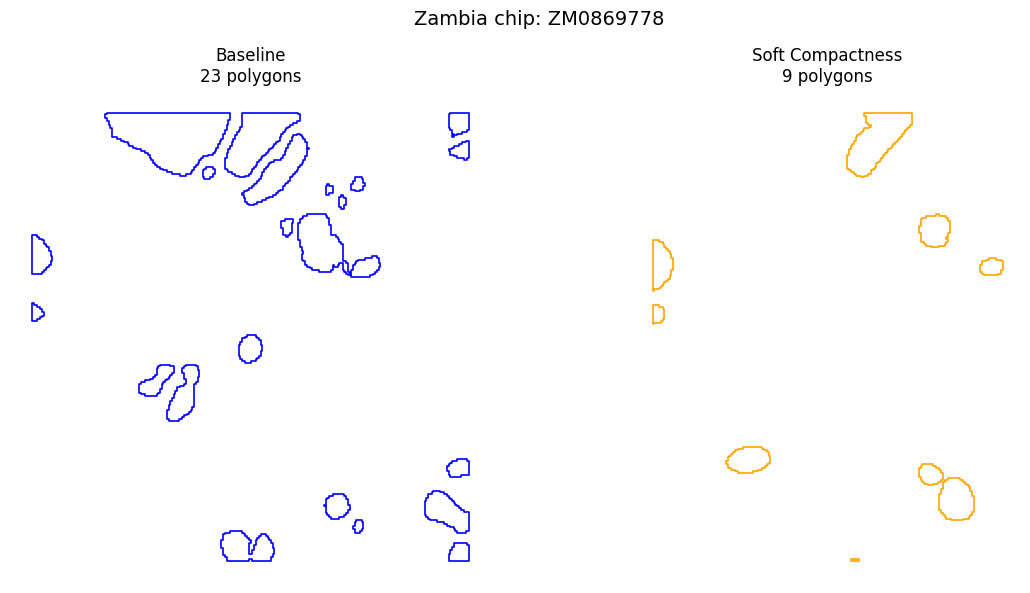

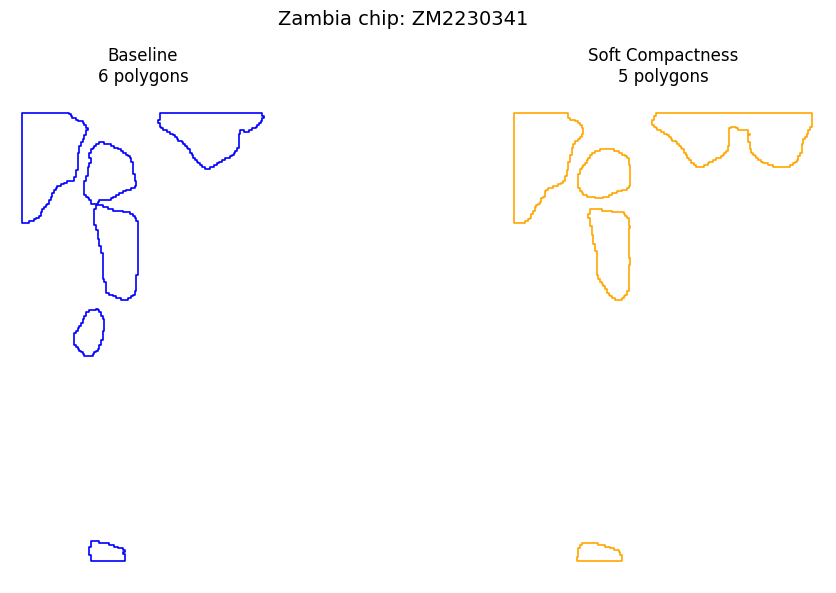

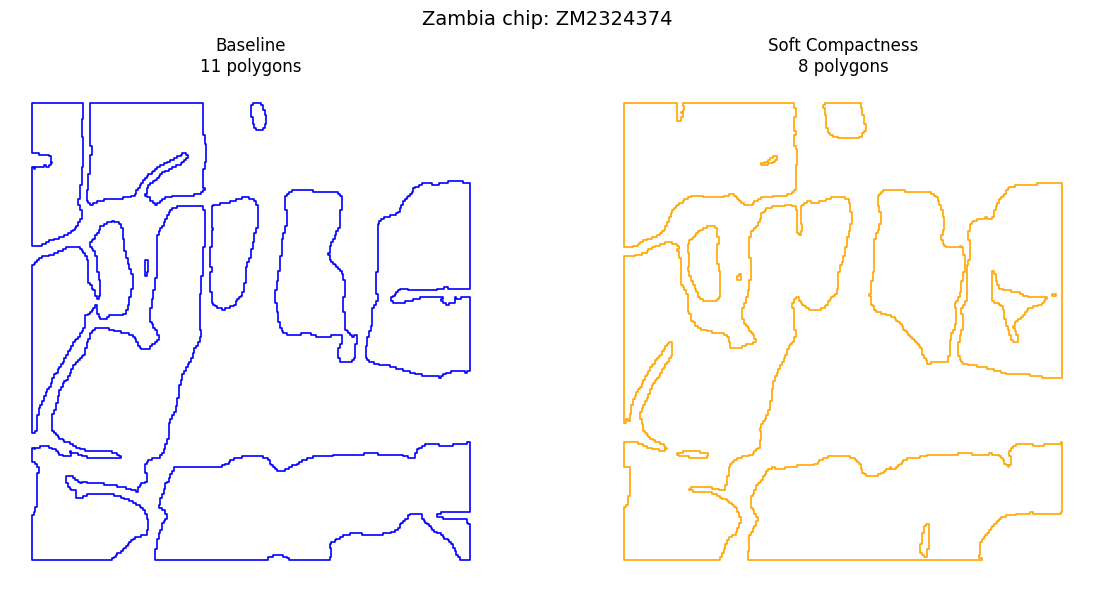

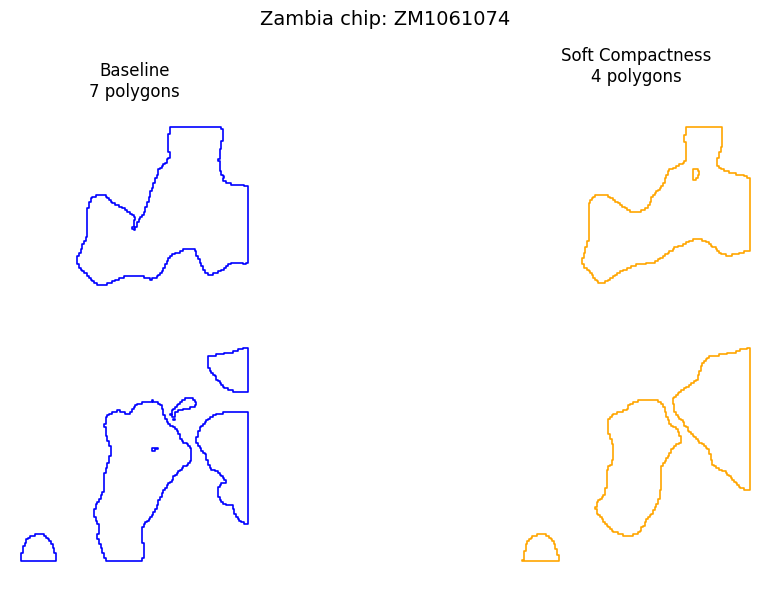

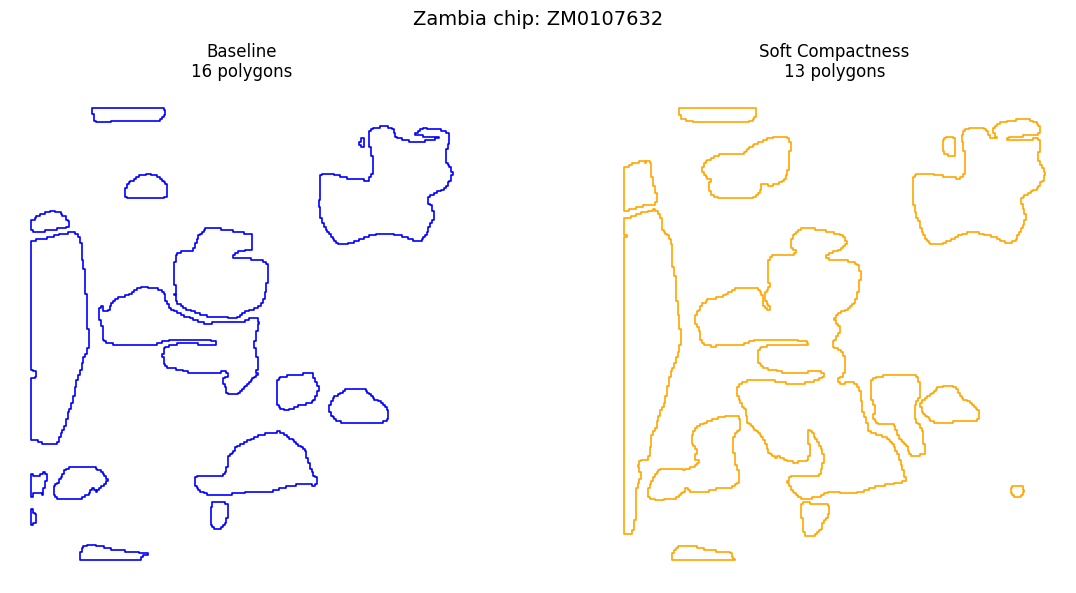

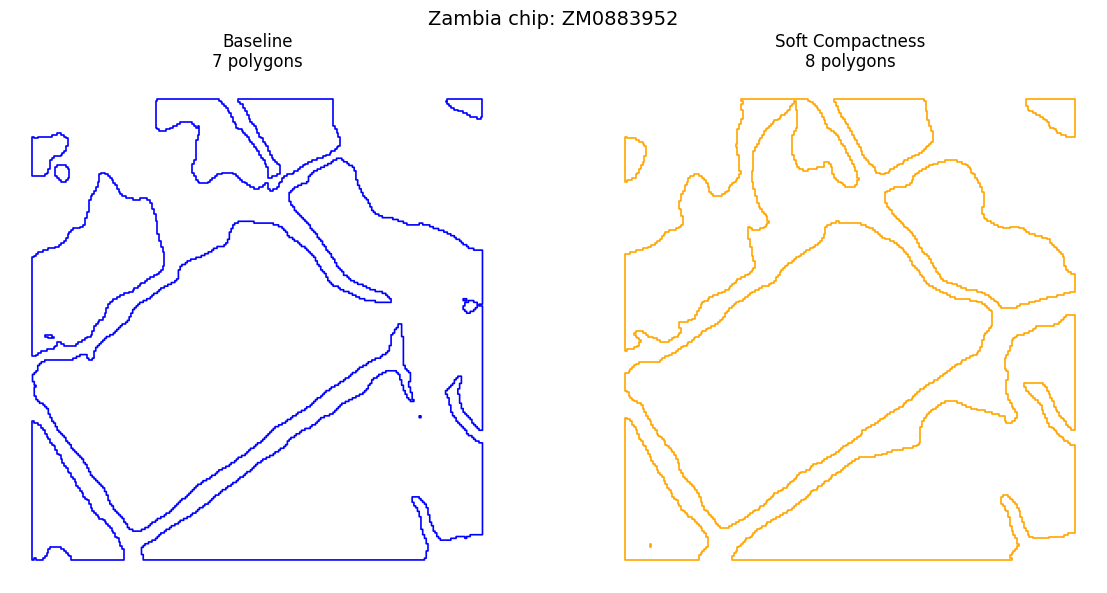

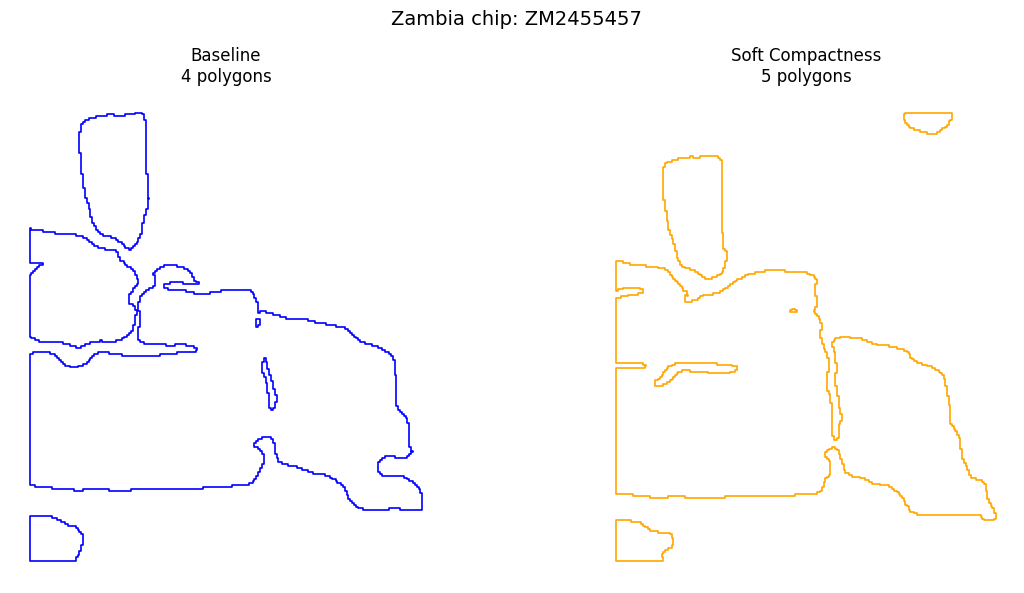

Saved 8 polygon comparison plots to: /opt/app-root/src/working/instances_direct/comparison_plots_polygons


In [7]:
from pathlib import Path
import random
import geopandas as gpd
import matplotlib.pyplot as plt

BASELINE_GPKG = Path("/opt/app-root/src/working/instances_direct/baseline_all_polygons.gpkg")
SOFT_GPKG = Path("/opt/app-root/src/working/instances_direct/soft_all_polygons.gpkg")

OUT_DIR = Path("/opt/app-root/src/working/instances_direct/comparison_plots_polygons")
OUT_DIR.mkdir(parents=True, exist_ok=True)

N = 8
# random.seed(42)

# Load data
baseline_gdf = gpd.read_file(BASELINE_GPKG)
soft_gdf = gpd.read_file(SOFT_GPKG)

print("Baseline polygons:", len(baseline_gdf))
print("Soft polygons:", len(soft_gdf))

# --------------------------------------------------
# Correct grouping key
# --------------------------------------------------
key_col = "chip_id"

baseline_ids = set(baseline_gdf[key_col].unique())
soft_ids = set(soft_gdf[key_col].unique())

common_ids = sorted(baseline_ids & soft_ids)

print("Common chips:", len(common_ids))

if len(common_ids) == 0:
    raise ValueError("No matching polygon groups found.")

sample_ids = random.sample(common_ids, min(N, len(common_ids)))

print("Selected chips:")
for chip_id in sample_ids:
    print(chip_id)

# --------------------------------------------------
# Plot
# --------------------------------------------------
for chip_id in sample_ids:
    base_chip = baseline_gdf[baseline_gdf[key_col] == chip_id]
    soft_chip = soft_gdf[soft_gdf[key_col] == chip_id]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    base_chip.plot(
        ax=axes[0],
        edgecolor="blue",
        facecolor="none",
        linewidth=1.2
    )
    axes[0].set_title(f"Baseline\n{len(base_chip)} polygons")

    soft_chip.plot(
        ax=axes[1],
        edgecolor="orange",
        facecolor="none",
        linewidth=1.2
    )
    axes[1].set_title(f"Soft Compactness\n{len(soft_chip)} polygons")

    for ax in axes:
        ax.set_axis_off()

    fig.suptitle(f"Zambia chip: {chip_id}", fontsize=14)
    plt.tight_layout()

    out_path = OUT_DIR / f"{chip_id}_polygons_comparison.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Saved {len(sample_ids)} polygon comparison plots to: {OUT_DIR}")

### Running Shape Metrics Compute on vectorized polygons

In [8]:
import numpy as np

def compute_shape_metrics(gdf):
    gdf = gdf.copy()

    # Ensure projected CRS (you already set ESRI:102022 earlier)
    gdf = gdf.to_crs("ESRI:102022")

    # Basic geometry
    gdf["area"] = gdf.geometry.area
    gdf["perimeter"] = gdf.geometry.length

    # -------------------------
    # Shape metrics
    # -------------------------

    # 1. Compactness (Polsby-Popper)
    gdf["compactness"] = (4 * np.pi * gdf["area"]) / (gdf["perimeter"] ** 2)

    # 2. Convexity
    gdf["convex_area"] = gdf.geometry.convex_hull.area
    gdf["convexity"] = gdf["area"] / gdf["convex_area"]

    # 3. Rectangularity
    gdf["bbox_area"] = gdf.geometry.envelope.area
    gdf["rectangularity"] = gdf["area"] / gdf["bbox_area"]

    # 4. Elongation (based on bounding box)
    bounds = gdf.geometry.bounds
    width = bounds["maxx"] - bounds["minx"]
    height = bounds["maxy"] - bounds["miny"]

    gdf["elongation"] = np.maximum(width, height) / np.minimum(width, height)

    return gdf

In [9]:
baseline_metrics = compute_shape_metrics(baseline_gdf)
soft_metrics = compute_shape_metrics(soft_gdf)

print("Baseline polygons:", len(baseline_metrics))
print("Soft polygons:", len(soft_metrics))

Baseline polygons: 3136
Soft polygons: 2788


In [10]:
def summarize_metrics(name, gdf):
    print(f"\n{name} SUMMARY")
    print("-" * 30)
    print("Mean area:", gdf["area"].mean())
    print("Mean compactness:", gdf["compactness"].mean())
    print("Mean convexity:", gdf["convexity"].mean())
    print("Mean rectangularity:", gdf["rectangularity"].mean())
    print("Mean elongation:", gdf["elongation"].mean())

summarize_metrics("BASELINE", baseline_metrics)
summarize_metrics("SOFT COMPACTNESS", soft_metrics)


BASELINE SUMMARY
------------------------------
Mean area: 7289.944792881011
Mean compactness: 0.46311303653492975
Mean convexity: 0.885148883667169
Mean rectangularity: 0.7057736160661549
Mean elongation: 1.7143437196539828

SOFT COMPACTNESS SUMMARY
------------------------------
Mean area: 8093.92460126665
Mean compactness: 0.4604887065784809
Mean convexity: 0.8916919574860465
Mean rectangularity: 0.7004151377252834
Mean elongation: 1.736262455923908


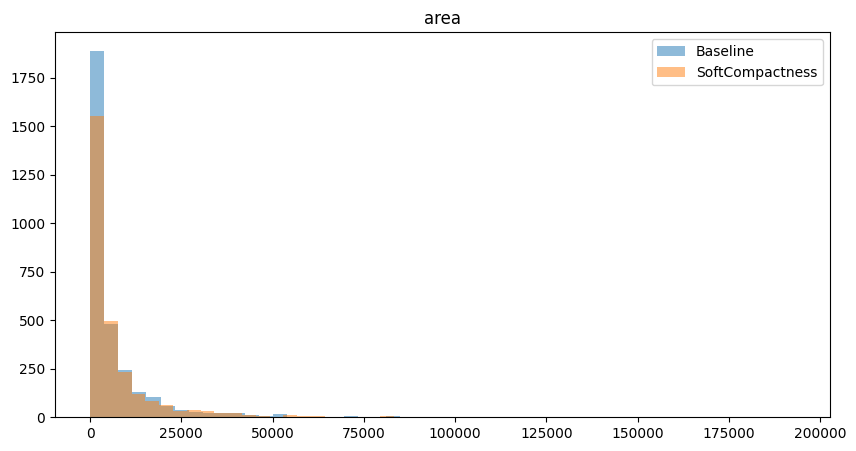

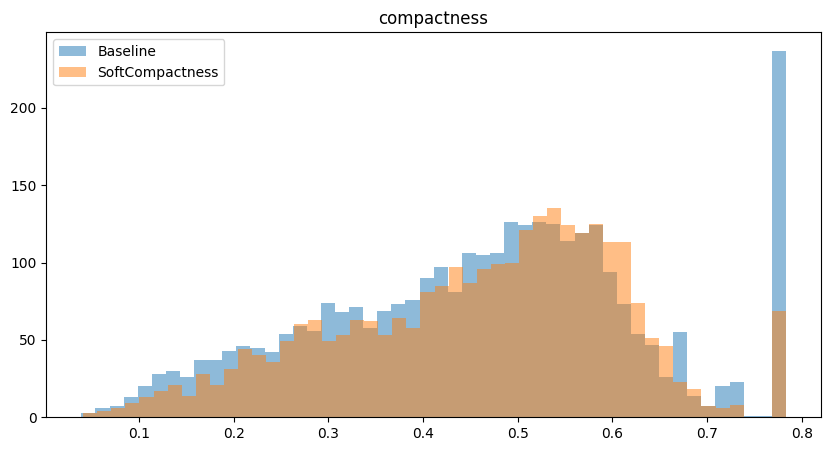

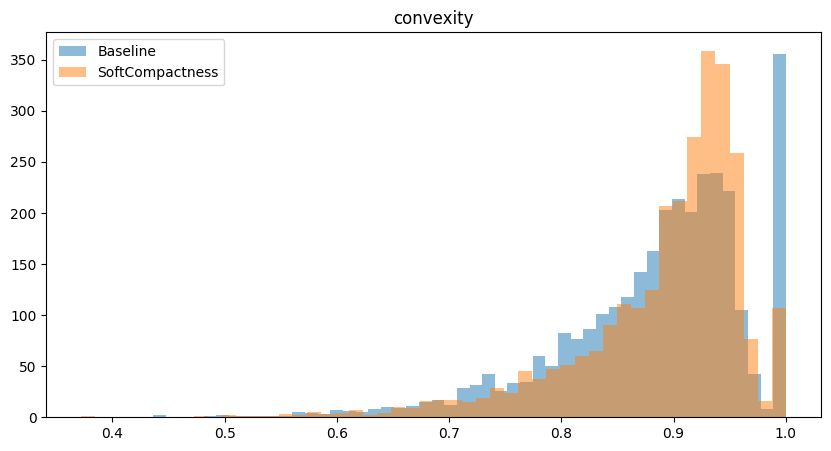

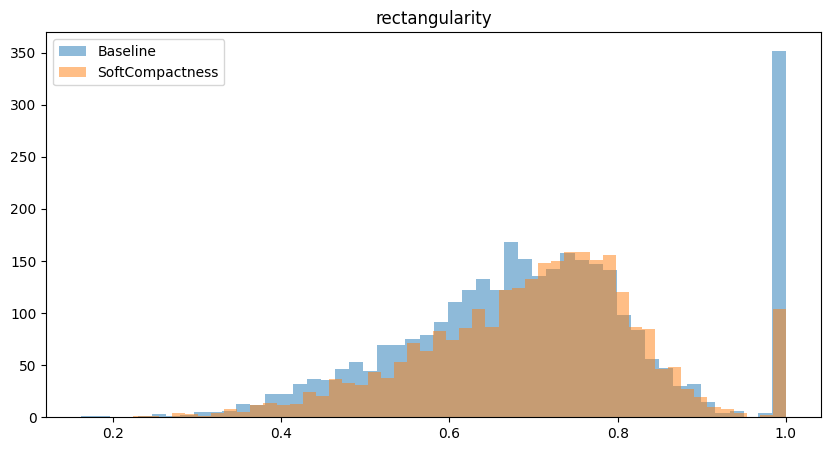

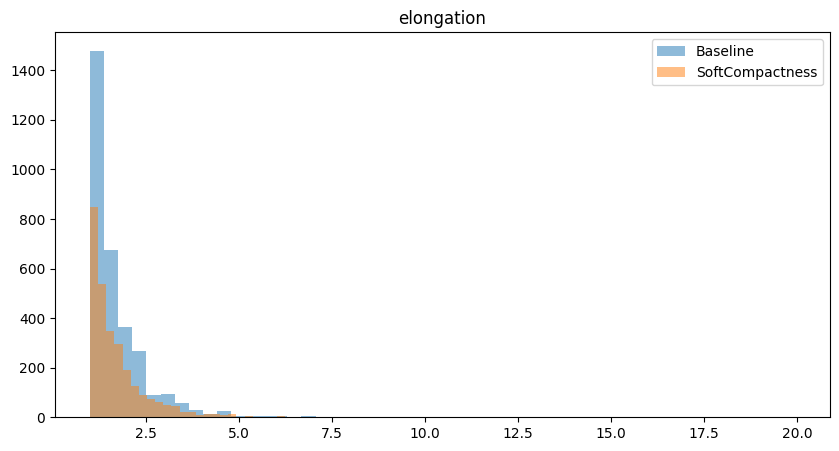

In [11]:
import matplotlib.pyplot as plt

def plot_hist(metric):
    plt.figure(figsize=(10,5))

    plt.hist(baseline_metrics[metric], bins=50, alpha=0.5, label="Baseline")
    plt.hist(soft_metrics[metric], bins=50, alpha=0.5, label="SoftCompactness")

    plt.title(metric)
    plt.legend()
    plt.show()

for m in ["area", "compactness", "convexity", "rectangularity", "elongation"]:
    plot_hist(m)